# Proyek Klasifikasi Gambar: Fruits-360
- **Nama:** Eko hendrawan
- **Email:** cacc288d6y2602@student.devacademy.id
- **ID Dicoding:** cacc288d6y2602

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preparation

### Data Loading

In [2]:
# Import module yang disediakan google colab untuk kebutuhan upload file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ekohendrawan","key":"60ea9592da0c40761792bd7658697cf2"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.46G/5.46G [00:42<00:00, 139MB/s]



In [5]:
!unzip fruits.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_17.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_173.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_177.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_181.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_185.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_189.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_193.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_197.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_201.jpg  
  inflating: fruits-360_original-size/fruits-360-or

#**Gabungkan Data Train dan Data Test ke Direktori yang Sama**

In [6]:
import os
import shutil

# Folder asli dataset
train_dir = "/content/fruits-360_100x100/fruits-360/Training"
test_dir = "/content/fruits-360_100x100/fruits-360/Test"

# Folder baru
combined_dir = "/content/fruits_dataset"

# 3 class
selected_classes = [
    "Apple 10",
    "Orange 1",
    "Pear 1"
]

# Buat folder dataset baru
os.makedirs(combined_dir, exist_ok=True)

# Gabungkan train + test
for category in selected_classes:

    train_category = os.path.join(train_dir, category)
    test_category = os.path.join(test_dir, category)

    target_category = os.path.join(combined_dir, category)

    os.makedirs(target_category, exist_ok=True)

    # Copy training
    if os.path.exists(train_category):
        for file in os.listdir(train_category):
            shutil.copy(
                os.path.join(train_category, file),
                os.path.join(target_category, file)
            )

    # Copy testing
    if os.path.exists(test_category):
        for file in os.listdir(test_category):
            shutil.copy(
                os.path.join(test_category, file),
                os.path.join(target_category, "test_" + file)
            )

print("Dataset berhasil digabung.")

Dataset berhasil digabung.


**Menghapus folder yang tidak terpakai**

In [7]:
!rm -rf /content/fruits-360_original-size

In [8]:
!rm -rf /content/fruits-360_multi
!rm -rf /content/fruits-360_meta
!rm -rf /content/fruits-360_3-body-problem

In [9]:
total = 0

for cls in os.listdir(combined_dir):

    cls_path = os.path.join(combined_dir, cls)

    if os.path.isdir(cls_path):

        jumlah = len(os.listdir(cls_path))

        print(f"{cls}: {jumlah} gambar")

        total += jumlah

print("\nTotal seluruh gambar:", total)

Pear 1: 656 gambar
Orange 1: 639 gambar
Apple 10: 930 gambar

Total seluruh gambar: 2225


## **Plot gambar sampel untuk semua kelas**

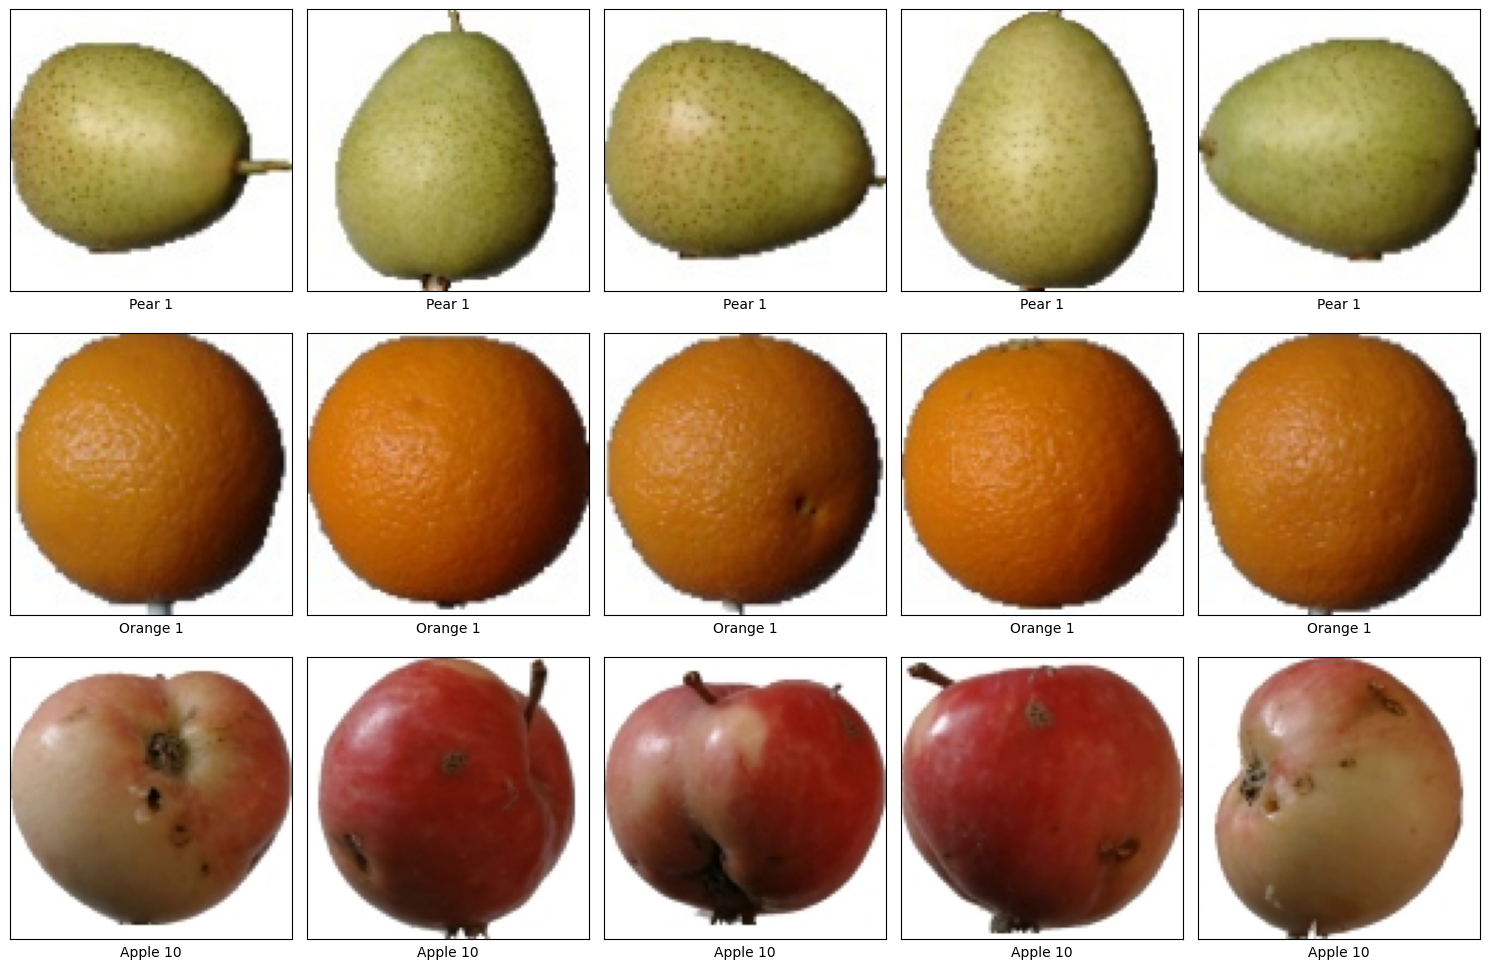

In [10]:
# Menyimpan gambar tiap kelas
fruit_image = {}

# Path dataset baru
path_sub = "/content/fruits_dataset"

# Ambil list gambar tiap class
for i in os.listdir(path_sub):
    fruit_image[i] = os.listdir(os.path.join(path_sub, i))

# Plot sample gambar
fig, axs = plt.subplots(len(fruit_image.keys()), 5, figsize=(15, 10))

for i, class_name in enumerate(os.listdir(path_sub)):

    # Ambil random 5 gambar
    images = np.random.choice(fruit_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):

        img_path = os.path.join(path_sub, class_name, image_name)

        # Open image RGB
        img = Image.open(img_path)

        axs[i, j].imshow(img)

        axs[i, j].set(
            xlabel=class_name,
            xticks=[],
            yticks=[]
        )

plt.tight_layout()
plt.show()

## **Plot distribusi gambar di seluruh kelas**


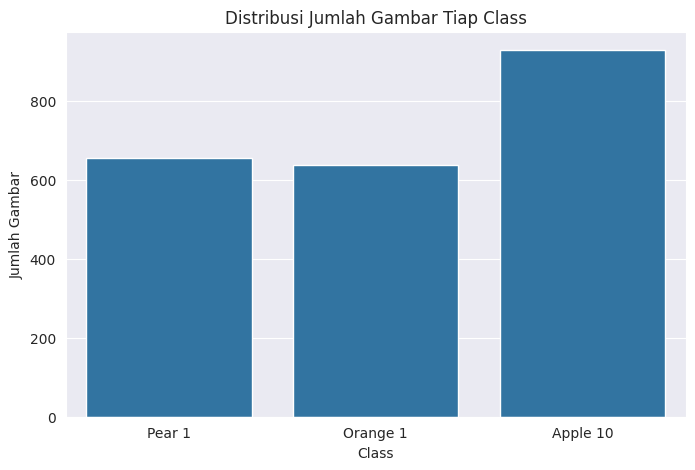

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define source path
fruit_path = "/content/fruits_dataset/"

# List penyimpanan data
file_name = []
labels = []
full_path = []

# Ambil semua filename, path, dan label
for path, subdirs, files in os.walk(fruit_path):

    for name in files:

        full_path.append(os.path.join(path, name))

        labels.append(path.split('/')[-1])

        file_name.append(name)

# Buat dataframe
distribution_data = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

# Plot distribusi gambar tiap class
plt.figure(figsize=(8,5))

sns.set_style("darkgrid")

sns.countplot(
    x='labels',
    data=distribution_data
)

plt.title("Distribusi Jumlah Gambar Tiap Class")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")

plt.show()

##Data preprocecsing


###Data augmentation



In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import random

IMG_SIZE = 100

# Fungsi rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.rot90(img, k=random.randint(1, 3))
    return img

# Fungsi rotasi searah jarum jam
def clockwise_rotation(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.rot90(img, k=4 - random.randint(1, 3))
    return img

# Fungsi flip horizontal
def flip_left_right(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.flip_left_right(img)
    return img

# Fungsi peningkatan kecerahan
def add_brightness(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.adjust_brightness(img, delta=random.uniform(0.1, 0.3))
    return img

# Fungsi shear
def sheared(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)).numpy()
    datagen = ImageDataGenerator(shear_range=0.2)
    img = next(iter(datagen.flow(np.expand_dims(img, 0), batch_size=1)))[0]
    return img

# Fungsi shifting
def warp_shift(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)).numpy()
    datagen = ImageDataGenerator(
        width_shift_range=0.1,
        height_shift_range=0.1
    )
    img = next(iter(datagen.flow(np.expand_dims(img, 0), batch_size=1)))[0]
    return img

In [13]:
import os
import cv2
import random
import numpy as np
import tensorflow as tf
from skimage import io, img_as_ubyte

# Daftar transformasi
transformations = {
    'rotate anticlockwise': anticlockwise_rotation,
    'rotate clockwise': clockwise_rotation,
    'warp shift': warp_shift,
    'add brightness': add_brightness,
    'flip left right': flip_left_right,
    'shear image': sheared
}

# Path dataset
dataset_path = "/content/fruits_dataset"

# Jumlah target gambar per class
target_per_class = 3500

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        os.path.join(class_path, im)
        for im in os.listdir(class_path)
        if im.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    current_count = len(images)
    images_to_generate = target_per_class - current_count

    print(f"{class_name}: {current_count} gambar, tambah {images_to_generate} gambar")

    if images_to_generate <= 0:
        continue

    i = 1

    while i <= images_to_generate:
        image_path = random.choice(images)

        try:
            original_image = io.imread(image_path)

            if original_image.ndim == 2:
                original_image = np.stack([original_image] * 3, axis=-1).astype(np.uint8)

            if original_image.shape[-1] == 4:
                original_image = original_image[..., :3]

            if original_image.dtype != np.uint8:
                original_image = img_as_ubyte(original_image)

            transformed_image = original_image
            transformation_count = random.randint(1, len(transformations))

            for _ in range(transformation_count):
                key = random.choice(list(transformations))
                transformed_image = transformations[key](transformed_image)

            transformed_image = tf.clip_by_value(transformed_image, 0, 255).numpy()
            transformed_image = transformed_image.astype(np.uint8)

            new_image_path = os.path.join(
                class_path,
                f"augmented_{class_name.replace(' ', '_')}_{i}.jpg"
            )

            cv2.imwrite(
                new_image_path,
                cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR)
            )

            i += 1

        except Exception as e:
            print(f"[SKIP] Failed processing {image_path}: {e}")

print("Augmentasi selesai.")

Pear 1: 656 gambar, tambah 2844 gambar
Orange 1: 639 gambar, tambah 2861 gambar
Apple 10: 930 gambar, tambah 2570 gambar
Augmentasi selesai.


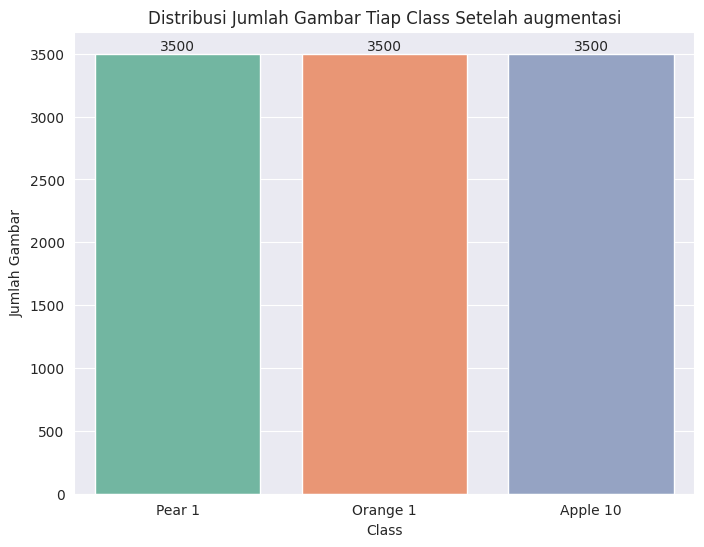

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define source path
fruit_path = "/content/fruits_dataset/"

# List penyimpanan data
file_name = []
labels = []
full_path = []

# Ambil semua filename, path, dan label
for path, subdirs, files in os.walk(fruit_path):

    for name in files:

        full_path.append(os.path.join(path, name))

        labels.append(path.split('/')[-1])

        file_name.append(name)

# Buat dataframe
distribution_train = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

# Plot distribusi class
plt.figure(figsize=(8,6))

sns.set_style("darkgrid")

plot_data = sns.countplot(
    x='labels',
    data=distribution_train,
    palette='Set2'
)

# Tambahkan jumlah di atas bar
for p in plot_data.patches:
    plot_data.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribusi Jumlah Gambar Tiap Class Setelah augmentasi")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")

plt.show()

#### Split Dataset

In [15]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Path dataset
mypath = "/content/fruits_dataset/"

# List penyimpanan
file_name = []
labels = []
full_path = []

# Ambil semua path gambar dan label
for path, subdirs, files in os.walk(mypath):

    for name in files:

        full_path.append(os.path.join(path, name))

        labels.append(path.split('/')[-1])

        file_name.append(name)

# Buat dataframe
df = pd.DataFrame({
    'path': full_path,
    'file_name': file_name,
    'labels': labels
})

# Cek jumlah data
print(df.groupby('labels').size())

# Pisah feature dan label
x = df['path']
y = df['labels']

# Split train dan temp
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Split validation dan test
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Dataframe train
df_train = pd.DataFrame({
    'path': x_train,
    'labels': y_train
})

# Dataframe validation
df_val = pd.DataFrame({
    'path': x_val,
    'labels': y_val
})

# Dataframe test
df_test = pd.DataFrame({
    'path': x_test,
    'labels': y_test
})

# Print hasil split
print("\nJumlah data:")
print("Train :", len(df_train))
print("Validation :", len(df_val))
print("Test :", len(df_test))

labels
Apple 10    3500
Orange 1    3500
Pear 1      3500
dtype: int64

Jumlah data:
Train : 7350
Validation : 1575
Test : 1575


In [16]:
import os
import shutil
from tqdm import tqdm

# Folder tujuan dataset final
dataset_path = "/content/Dataset-Final"

# Gabungkan dataframe train, validation, test
df_train['set'] = 'train'
df_val['set'] = 'validation'
df_test['set'] = 'test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Copy file ke folder baru
for index, row in tqdm(df_all.iterrows(), total=len(df_all)):
    file_path = row['path']
    label = row['labels']
    set_name = row['set']

    target_dir = os.path.join(dataset_path, set_name, label)
    os.makedirs(target_dir, exist_ok=True)

    destination_file = os.path.join(target_dir, os.path.basename(file_path))

    if not os.path.exists(destination_file):
        shutil.copy(file_path, destination_file)

print("Dataset final berhasil dibuat.")

100%|██████████| 10500/10500 [00:03<00:00, 3078.75it/s]

Dataset final berhasil dibuat.


In [17]:
for split in ['train', 'validation', 'test']:
    print(f"\n{split.upper()}")
    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        print(cls, len(os.listdir(cls_path)))


TRAIN
Pear 1 2450
Orange 1 2450
Apple 10 2450

VALIDATION
Pear 1 525
Orange 1 525
Apple 10 525

TEST
Pear 1 525
Orange 1 525
Apple 10 525


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Direktori dataset final
TRAIN_DIR = "/content/Dataset-Final/train"
VAL_DIR = "/content/Dataset-Final/validation"
TEST_DIR = "/content/Dataset-Final/test"

# ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Generator train
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(100, 100),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

# Generator validation
validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(100, 100),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Generator test
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(100, 100),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

Found 7350 images belonging to 3 classes.
Found 1575 images belonging to 3 classes.
Found 1575 images belonging to 3 classes.


## Modelling

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()

######################### Input layer with Fully Connected Layer ################################

# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(100, 100, 3)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())

# 1st Dense Layer
model_1.add(Dense(128, activation='relu'))

# 1st Dropout Layer
model_1.add(Dropout(0.5))

# 2nd Dense Layer
model_1.add(Dense(64, activation='relu'))

# 2nd Dropout Layer
model_1.add(Dropout(0.3))

# Final Dense layer => For output prediction 3 classes, softmax for multiclass cases
model_1.add(Dense(3, activation='softmax'))

######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,307 (2.54 MB)

 Trainable params: 666,115 (2.54 MB)

 Non-trainable params: 192 (768.00 B)

None


In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

%time

history_1 = model_1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=callbacks
)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.72 µs
Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9853 - loss: 0.0669 - val_accuracy: 0.4597 - val_loss: 5.2071 - learning_rate: 0.0010
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 3.7844e-10 - learning_rate: 0.0010
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 3.9358e-09 - learning_rate: 0.0010
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9995 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9997 - loss: 8.5671e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 1.0000 - loss: 1.3335e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rat

## Evaluasi dan Visualisasi

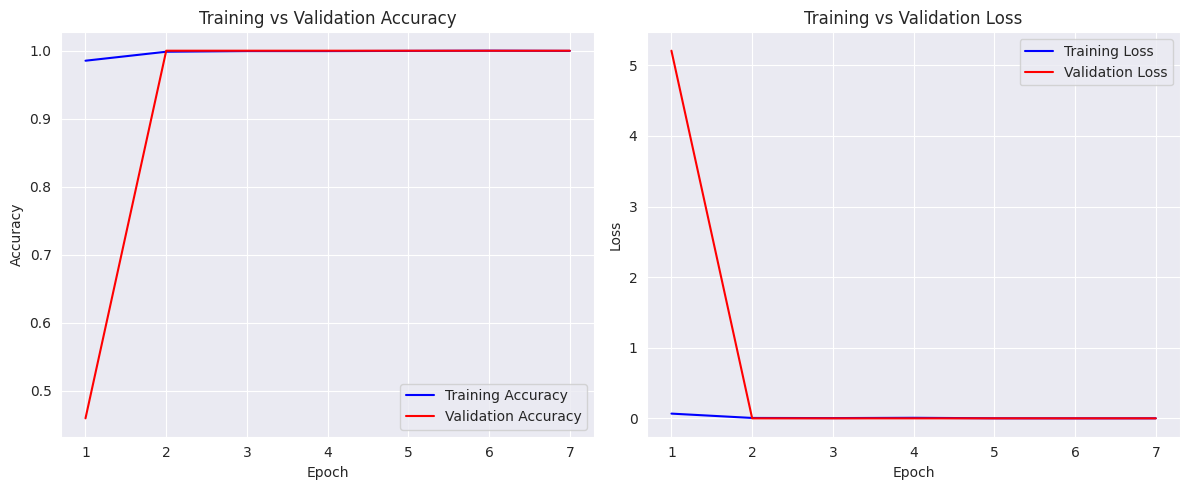

In [21]:
import matplotlib.pyplot as plt

# Ambil history training
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']

loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(1, len(acc) + 1)

# =========================
# Plot Accuracy
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# =========================
# Plot Loss
# =========================
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step


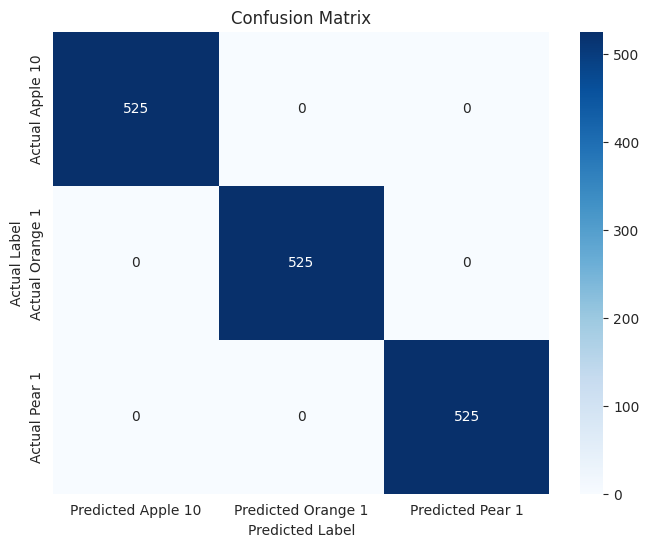


Classification Report:
              precision    recall  f1-score   support

    Apple 10     1.0000    1.0000    1.0000       525
    Orange 1     1.0000    1.0000    1.0000       525
      Pear 1     1.0000    1.0000    1.0000       525

    accuracy                         1.0000      1575
   macro avg     1.0000    1.0000    1.0000      1575
weighted avg     1.0000    1.0000    1.0000      1575



In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

# Reset generator test
test_generator.reset()

# Prediksi data test
preds_1 = model_1.predict(test_generator, verbose=1)

# Ambil class dengan probabilitas tertinggi
y_pred = np.argmax(preds_1, axis=1)

# Label asli
y_true = test_generator.classes

# Nama class
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

## Konversi Model

In [26]:
import tensorflow as tf

saved_model_path = "/content/saved_model"

# Simpan model format SavedModel
model_1.export(saved_model_path)

print("SavedModel berhasil disimpan di:", saved_model_path)

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136237628631056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628631824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628632592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628632976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628628176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628631248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628632208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628633936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628634320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237628635472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1362376286

In [27]:
import os
import tensorflow as tf

# Buat folder tflite
os.makedirs("/content/tflite", exist_ok=True)

# Convert SavedModel ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("/content/saved_model")
tflite_model = converter.convert()

# Simpan model.tflite
with open("/content/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

# Simpan label.txt
labels = list(train_generator.class_indices.keys())

with open("/content/tflite/label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

print("TFLite berhasil dibuat.")
print(os.listdir("/content/tflite"))

TFLite berhasil dibuat.
['model.tflite', 'label.txt']


In [1]:
!pip install tensorflowjs

In [2]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  /content/saved_model \
  /content/tfjs_model

import os
print("TFJS berhasil dibuat.")
print(os.listdir("/content/tfjs_model"))

2026-05-11 16:31:40.017056: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 16:31:40.024254: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 16:31:40.058135: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778517100.143661   16871 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778517100.157488   16871 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778517100.185915   16871 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Inference (Optional)

Saving apel.jpg to apel (2).jpg


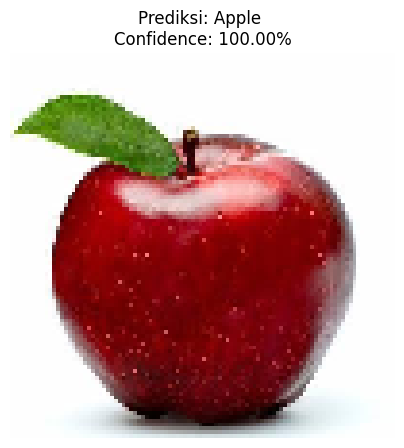

Hasil Prediksi : Apple 
Confidence : 100.0 %


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from google.colab import files

# =========================
# Load SavedModel
# =========================
model_1 = tf.keras.layers.TFSMLayer(
    "/content/saved_model",
    call_endpoint='serve'
)

# =========================
# Upload Image
# =========================
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# =========================
# Preprocessing
# =========================
img = image.load_img(file_name, target_size=(100,100))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

# =========================
# Predict
# =========================
prediction = model_1(img_array)

prediction = np.array(prediction)

predicted_class_index = np.argmax(prediction)

class_names = [
    "Apple ",
    "Orange ",
    "Pear "
]

predicted_class = class_names[predicted_class_index]

confidence = np.max(prediction) * 100

# =========================
# Show Result
# =========================
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')

plt.title(
    f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

print("Hasil Prediksi :", predicted_class)
print("Confidence :", round(confidence, 2), "%")